Dataset shape: (442, 10)
Median progression score used as threshold: 140.5
Diabetes        221
Not Diabetes    221
Name: count, dtype: int64
--- Logistic Regression ---
Accuracy: 0.7416  Precision: 0.7143  Recall: 0.7955  F1: 0.7527
              precision    recall  f1-score   support

Not Diabetes       0.78      0.69      0.73        45
    Diabetes       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89

--- SVM ---
Accuracy: 0.7416  Precision: 0.7143  Recall: 0.7955  F1: 0.7527
              precision    recall  f1-score   support

Not Diabetes       0.78      0.69      0.73        45
    Diabetes       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



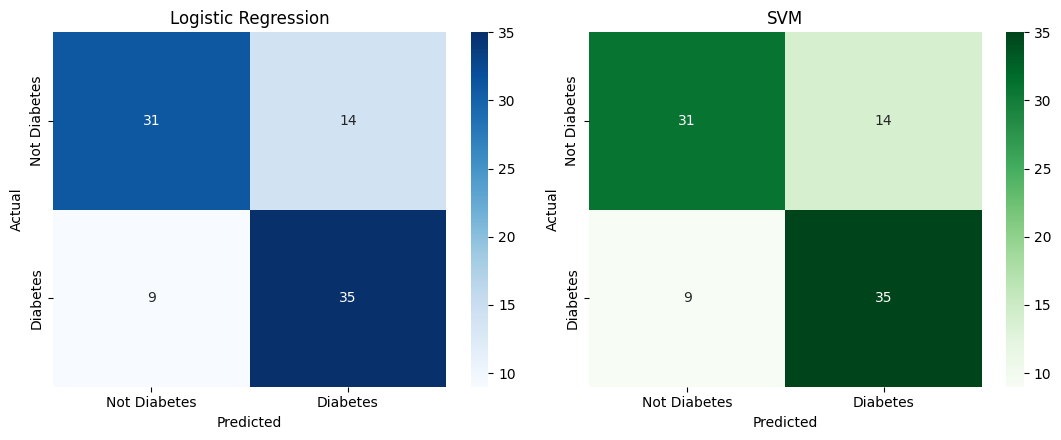

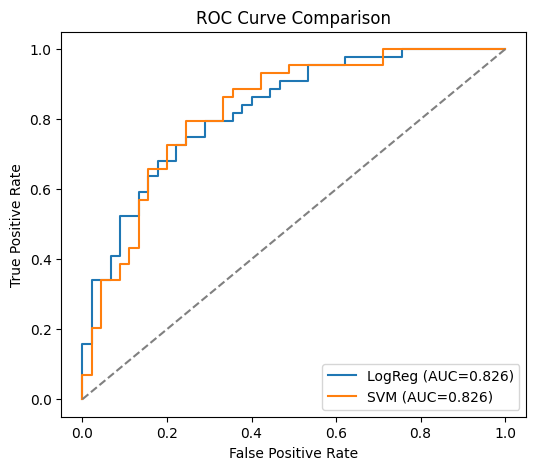

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.741573   0.714286  0.795455  0.752688
1                  SVM  0.741573   0.714286  0.795455  0.752688


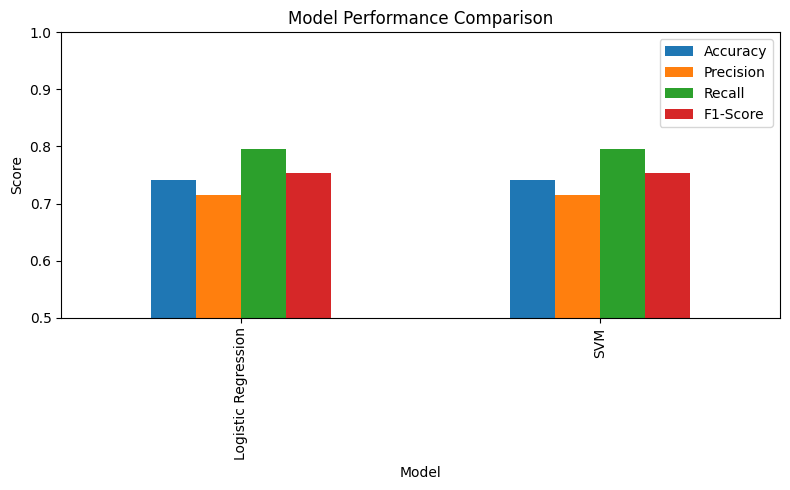


Prediction for sample patient: DIABETES
Probability -> Not Diabetes: 0.1629, Diabetes: 0.8371


In [6]:
# Joy Kumar Dey
# M.SC. in IICT (ID: 2671506)
# Task (Course code: ICT 6700)
# Disease Prediction: Diabetes / Not Diabetes (sklearn.datasets.load_diabetes)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc)

# 1. Load Dataset directly from Scikit-learn
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_continuous = data.target   # quantitative disease progression score, 1 year after baseline
threshold = np.median(y_continuous)
y = (y_continuous > threshold).astype(int)   # 1 = Diabetes, 0 = Not Diabetes
print("Dataset shape:", X.shape)
print("Median progression score used as threshold:", threshold)
print(pd.Series(y).map({0: "Not Diabetes", 1: "Diabetes"}).value_counts())
X.head()

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# 5. Support Vector Machine (SVM)
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)
y_prob_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation Function
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=["Not Diabetes", "Diabetes"]))
    return acc, prec, rec, f1

lr_metrics = evaluate(y_test, y_pred_lr, "Logistic Regression")
svm_metrics = evaluate(y_test, y_pred_svm, "SVM")

# 7. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Diabetes", "Diabetes"], yticklabels=["Not Diabetes", "Diabetes"])
axes[0].set_title("Logistic Regression"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Not Diabetes", "Diabetes"], yticklabels=["Not Diabetes", "Diabetes"])
axes[1].set_title("SVM"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

# 8. ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc(fpr_lr,tpr_lr):.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc(fpr_svm,tpr_svm):.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison"); plt.legend(); plt.show()

# 9. Model Comparison Table & Chart
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [lr_metrics[0], svm_metrics[0]],
    "Precision": [lr_metrics[1], svm_metrics[1]],
    "Recall": [lr_metrics[2], svm_metrics[2]],
    "F1-Score": [lr_metrics[3], svm_metrics[3]],
})
print(results)
results.set_index("Model").plot(kind="bar", figsize=(8,5), ylim=(0.5,1.0))
plt.title("Model Performance Comparison"); plt.ylabel("Score"); plt.tight_layout(); plt.show()

# 10. Predict Diabetes / Not Diabetes for a New Patient (demo, using SVM)
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
pred = svm_clf.predict(sample_scaled)[0]
prob = svm_clf.predict_proba(sample_scaled)[0]
print("\nPrediction for sample patient:", "DIABETES" if pred == 1 else "NOT DIABETES")
print(f"Probability -> Not Diabetes: {prob[0]:.4f}, Diabetes: {prob[1]:.4f}")